In [35]:
import ccxt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_ta as ta
import scipy.stats as stats
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
SYMBOL = 'BTC/USDT'
TIMEFRAME = '1d'
LOOKBACK_DAYS = 1825
INITIAL_CAPITAL = 1000
LEVERAGE = 1

def fetch_data():
    exchange = ccxt.binance({'enableRateLimit': True, 'options': {'defaultType': 'future'}})
    now = exchange.milliseconds()
    since = now - (LOOKBACK_DAYS * 24 * 60 * 60 * 1000)
    all_ohlcv = []
    
    print(f"Fetching OHLCV for {SYMBOL}...")
    while since < now:
        try:
            ohlcv = exchange.fetch_ohlcv(SYMBOL, TIMEFRAME, since, limit=1000)
            if not ohlcv: break
            all_ohlcv.extend(ohlcv)
            since = ohlcv[-1][0] + 1
            if len(ohlcv) < 1000: break
        except Exception as e:
            break

    df = pd.DataFrame(all_ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('datetime', inplace=True)
    return df[~df.index.duplicated(keep='first')]

def fetch_funding_data():
    exchange = ccxt.binance({'enableRateLimit': True, 'options': {'defaultType': 'future'}})
    now = exchange.milliseconds()
    since = now - (LOOKBACK_DAYS * 24 * 60 * 60 * 1000)
    all_funding = []
    
    print(f"Fetching Funding Rates for {SYMBOL}...")
    while since < now:
        try:
            funding = exchange.fetch_funding_rate_history(SYMBOL, since=since, limit=1000)
            if not funding: break
            all_funding.extend(funding)
            since = funding[-1]['timestamp'] + 1
            if len(funding) < 1000: break
        except Exception as e:
            break

    df_funding = pd.DataFrame(all_funding)
    if not df_funding.empty:
        df_funding['datetime'] = pd.to_datetime(df_funding['timestamp'], unit='ms')
        df_funding.set_index('datetime', inplace=True)
        df_funding = df_funding[~df_funding.index.duplicated(keep='first')]
        df_funding = df_funding[['fundingRate']]
        df_funding['fundingRate'] = pd.to_numeric(df_funding['fundingRate'])
    return df_funding

df = fetch_data()
df_fund = fetch_funding_data()
print("✅ Cell 1 Complete: Data Downloaded.")

Fetching OHLCV for BTC/USDT...
Fetching Funding Rates for BTC/USDT...
✅ Cell 1 Complete: Data Downloaded.


In [36]:
# 1. Merge and forward-fill
btc_data = df.join(df_fund, how='left').ffill().dropna()

# 2. Feature Engineering for ML Validation
btc_data['RSI'] = btc_data.ta.rsi(length=14)
btc_data['ATR'] = btc_data.ta.atr(length=14)
btc_data['ROC'] = btc_data.ta.roc(length=12)

bbands = btc_data.ta.bbands(length=20, std=2)
btc_data['BBM'] = bbands.iloc[:, 1]
btc_data['BBB'] = bbands.iloc[:, 3]
btc_data['BBP'] = bbands.iloc[:, 4]

btc_data['OBV'] = btc_data.ta.obv()
btc_data['volume_change'] = btc_data['volume'].pct_change()

btc_data['future_return'] = btc_data['close'].pct_change().shift(-1)
btc_data['target'] = np.where(btc_data['future_return'] > 0, 1, 0)
btc_data['market_return'] = btc_data['close'].pct_change()

btc_data.dropna(inplace=True)
print("✅ Cell 2 Complete: Features Engineered.")

✅ Cell 2 Complete: Features Engineered.


BTC 1d Return Skewness: -0.0032


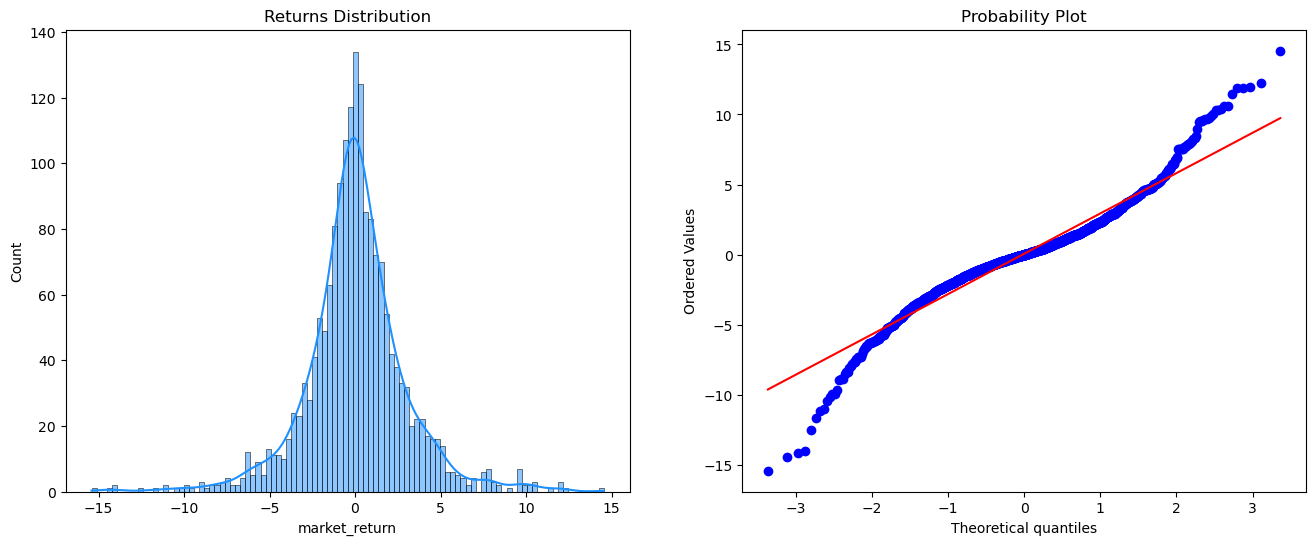

In [37]:
clean_returns = btc_data['market_return'].dropna()
btc_skew = clean_returns.skew()
print(f"BTC {TIMEFRAME} Return Skewness: {btc_skew:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(clean_returns * 100, bins=100, color='dodgerblue', kde=True, ax=axes[0])
axes[0].set_title('Returns Distribution')
stats.probplot(clean_returns * 100, dist="norm", plot=axes[1])
plt.show()

✅ Model saved to xgboost_model.json
              precision    recall  f1-score   support

           0       0.51      0.67      0.58       182
           1       0.50      0.34      0.41       179

    accuracy                           0.51       361
   macro avg       0.51      0.51      0.49       361
weighted avg       0.51      0.51      0.49       361

Accuracy: 0.5069252077562327


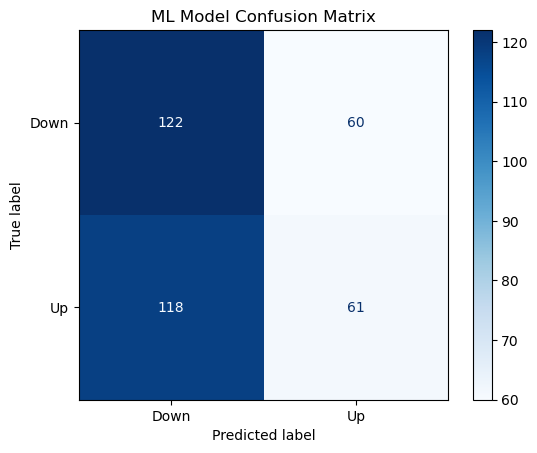

✅ XGBoost Model Trained.


In [38]:
# --- XGBOOST MODEL TRAINING ---
features = ['RSI', 'ATR', 'ROC', 'BBM', 'BBB', 'BBP', 'OBV', 'volume_change', 'fundingRate']
X = btc_data[features]
y = btc_data['target']

split_idx = int(len(btc_data) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

model = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='logloss')
model.fit(X_train, y_train)

model.save_model("xgboost_model.json")
print("✅ Model saved to xgboost_model.json")

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
disp.plot(cmap='Blues')
plt.title('ML Model Confusion Matrix')
plt.show()

btc_data['ml_signal'] = model.predict(X)
print("✅ XGBoost Model Trained.")

✅ Strategy Applied.


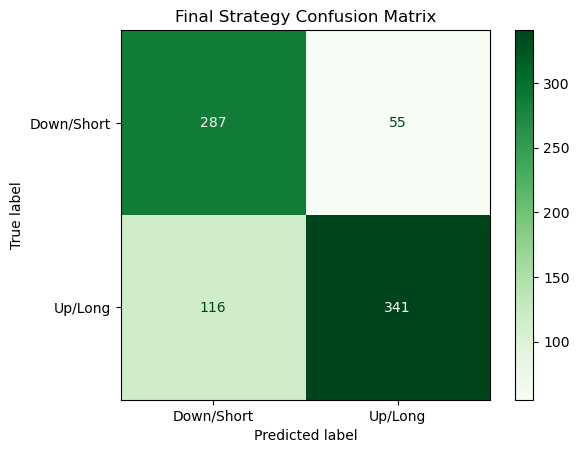

In [39]:
# --- DONCHIAN BREAKOUT + ML VALIDATION ---
DONCHIAN_WINDOW = 20
TAKER_FEE = 0.0005 

dc = ta.donchian(btc_data["high"], btc_data["low"], lower_length=DONCHIAN_WINDOW, upper_length=DONCHIAN_WINDOW)
btc_data["DCU"] = dc[f"DCU_{DONCHIAN_WINDOW}_{DONCHIAN_WINDOW}"]
btc_data["DCL"] = dc[f"DCL_{DONCHIAN_WINDOW}_{DONCHIAN_WINDOW}"]

btc_data["raw_dc_signal"] = np.nan
btc_data.loc[btc_data["close"] > btc_data["DCU"].shift(1), "raw_dc_signal"] = 1
btc_data.loc[btc_data["close"] < btc_data["DCL"].shift(1), "raw_dc_signal"] = -1
btc_data["raw_dc_signal"] = btc_data["raw_dc_signal"].ffill().fillna(0)

btc_data["validated_position"] = 0
btc_data.loc[(btc_data["raw_dc_signal"] == 1) & (btc_data["ml_signal"] == 1), "validated_position"] = 1
btc_data.loc[(btc_data["raw_dc_signal"] == -1) & (btc_data["ml_signal"] == 0), "validated_position"] = -1

btc_data["strat_return_gross"] = btc_data["validated_position"].shift(1) * btc_data["future_return"] * LEVERAGE
btc_data["strat_pos_change"] = btc_data["validated_position"].diff().abs().fillna(0)
btc_data["strat_return_net"] = btc_data["strat_return_gross"] - (btc_data["strat_pos_change"] * TAKER_FEE * LEVERAGE)

btc_data["cum_market"] = INITIAL_CAPITAL * (1 + btc_data["market_return"]).cumprod()
btc_data["cum_strategy"] = INITIAL_CAPITAL * (1 + btc_data["strat_return_net"].fillna(0)).cumprod()
print("✅ Strategy Applied.")

trades = btc_data[btc_data['validated_position'] != 0]
if not trades.empty:
    cm_strat = confusion_matrix(trades['target'], (trades['validated_position'] == 1).astype(int))
    disp_strat = ConfusionMatrixDisplay(confusion_matrix=cm_strat, display_labels=['Down/Short', 'Up/Long'])
    disp_strat.plot(cmap='Greens')
    plt.title('Final Strategy Confusion Matrix')
    plt.show()

Strategy Final Value: $1885.56
Sharpe Ratio: 0.53
Max Drawdown: -39.12%


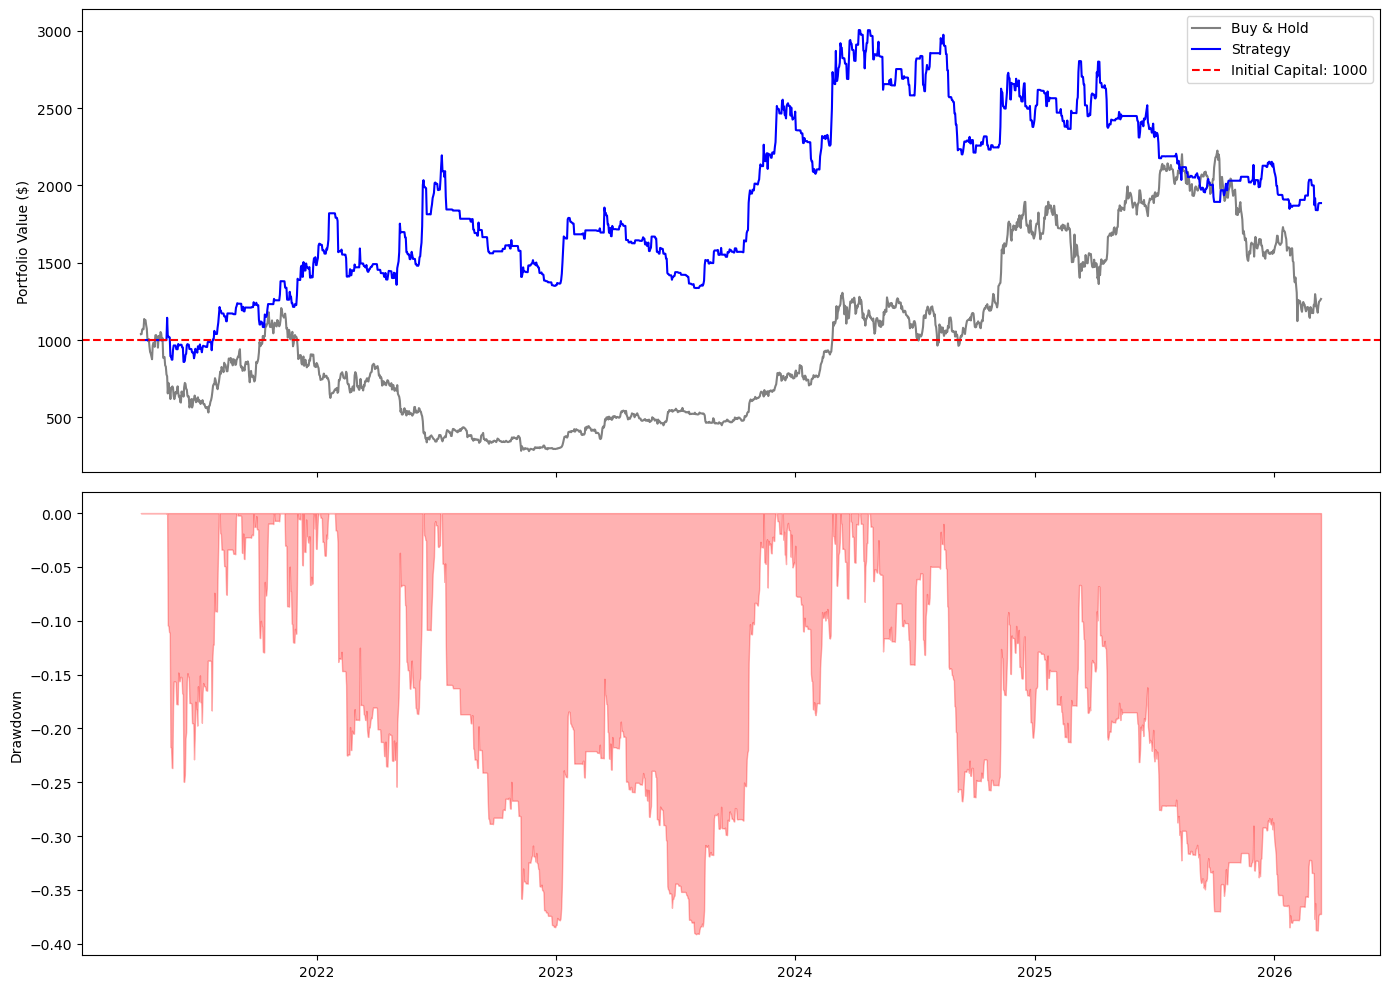

In [40]:
# --- FINAL PERFORMANCE --- 
ANNUAL_FACTOR = 1 * 365
mean_ret = btc_data['strat_return_net'].mean()
std_ret = btc_data['strat_return_net'].std()
sharpe = (mean_ret / std_ret) * np.sqrt(ANNUAL_FACTOR) if std_ret > 0 else 0

running_max = btc_data['cum_strategy'].cummax()
drawdown = (btc_data['cum_strategy'] - running_max) / running_max
max_dd = drawdown.min()

print(f"Strategy Final Value: ${btc_data['cum_strategy'].iloc[-1]:.2f}")
print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Max Drawdown: {max_dd*100:.2f}%")

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
axes[0].plot(btc_data.index, btc_data['cum_market'], color='gray', label='Buy & Hold')
axes[0].plot(btc_data.index, btc_data['cum_strategy'], color='blue', label='Strategy')
axes[0].axhline(y=INITIAL_CAPITAL, color='r', linestyle='--', label=f'Initial Capital: {INITIAL_CAPITAL}')
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].legend()
axes[1].fill_between(btc_data.index, drawdown, 0, color='red', alpha=0.3)
axes[1].set_ylabel('Drawdown')
plt.tight_layout()
plt.show()